# Escoamento Potencial — Superposição Numérica de Fontes/Sumidouros

Tradução em Python dos scripts MATLAB da pasta `Potential Flow`
(`uniform_flow.m`, `source_flow.m`, `plot_flow.m`, `potential_flow.m`).

O modelo constrói o **potencial de velocidades** $\phi(x,y)$ numa malha discreta por
superposição de um escoamento uniforme com múltiplas fontes/sumidouros pontuais, obtém o
campo de velocidades por diferenciação numérica de $\phi$ ($\vec{u}=\nabla\phi$), e traça
as linhas de corrente resultantes junto com as linhas equipotenciais.

No script principal, dois pares de fonte+sumidouro muito próximos (aproximando dois
dipolos) são posicionados simetricamente em $y=\pm0.1$, simulando o escoamento uniforme
perturbado por dois corpos delgados alinhados horizontalmente.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.style.use('ggplot')

## Funções de superposição de escoamentos potenciais

`uniform_flow` soma ao potencial a contribuição de um escoamento uniforme $(u,v)$:
$\phi \mathrel{+}= ux+vy$. `source_flow` soma a contribuição de uma fonte ($q>0$) ou
sumidouro ($q<0$) de intensidade $q$ localizado em $(x_0,y_0)$: $\phi \mathrel{+}=
\dfrac{q}{2\pi}\ln r$, com $r$ a distância até $(x_0,y_0)$.

In [2]:
def uniform_flow(P, X, Y, u, v):
    """Soma ao potencial P a contribuição de um escoamento uniforme (u, v)."""
    return P + u * X + v * Y


def source_flow(P, X, Y, x0, y0, q):
    """Soma ao potencial P a contribuição de uma fonte (q>0) ou sumidouro (q<0)
    de intensidade q localizada em (x0, y0)."""
    r = np.sqrt((X - x0) ** 2 + (Y - y0) ** 2)
    with np.errstate(divide='ignore'):
        return P + q / (2 * np.pi) * np.log(r)

## Visualização: velocidade e linhas de corrente a partir do potencial

`plot_flow` deriva o campo de velocidades $(U,V)$ do potencial $P=\phi$ por diferenças
finitas (`np.gradient`, equivalente ao `gradient` do MATLAB), normalizando pelo espaçamento
real da malha, e então traça as linhas de corrente (integração do campo de velocidades a
partir de uma linha de sementes verticais em $x=0.1$) sobrepostas às curvas de nível do
potencial (linhas equipotenciais, perpendiculares às linhas de corrente).

In [3]:
def plot_flow(P, X, Y):
    """Calcula o campo de velocidades a partir do potencial P por diferenciação
    numérica e plota as linhas de corrente e as linhas equipotenciais."""
    dPdrow, dPdcol = np.gradient(P)   # (d/eixo-linha, d/eixo-coluna) = (dP/dy_idx, dP/dx_idx)
    _, hx = np.gradient(X)            # variação de X ao longo das colunas (direção x)
    hy, _ = np.gradient(Y)            # variação de Y ao longo das linhas (direção y)

    U = dPdcol / hx
    V = dPdrow / hy

    n_streams = 30
    seed_y = np.linspace(Y[0, 0], Y[-1, -1], n_streams)
    seed_x = 0.1 * np.ones(n_streams)
    seeds = np.column_stack([seed_x, seed_y])

    plt.figure(figsize=(10, 6))
    plt.streamplot(X[0, :], Y[:, 0], U, V, start_points=seeds,
                    density=20, color='b', linewidth=0.8, integration_direction='both')
    plt.contour(X, Y, P, levels=30, colors='r', linewidths=0.6)
    plt.axis('equal')
    plt.xlabel('x'); plt.ylabel('y')
    plt.show()

## Script principal — par de dipolos em escoamento uniforme

Monta a malha do domínio, inicializa o potencial com um escoamento uniforme horizontal
($u=1$, $v=0$) e soma dois pares de fonte/sumidouro quase coincidentes (separação de
$0.002$ em $x$), um em $y=0.1$ e outro em $y=-0.1$ — cada par aproxima um dipolo — antes de
visualizar o escoamento resultante.

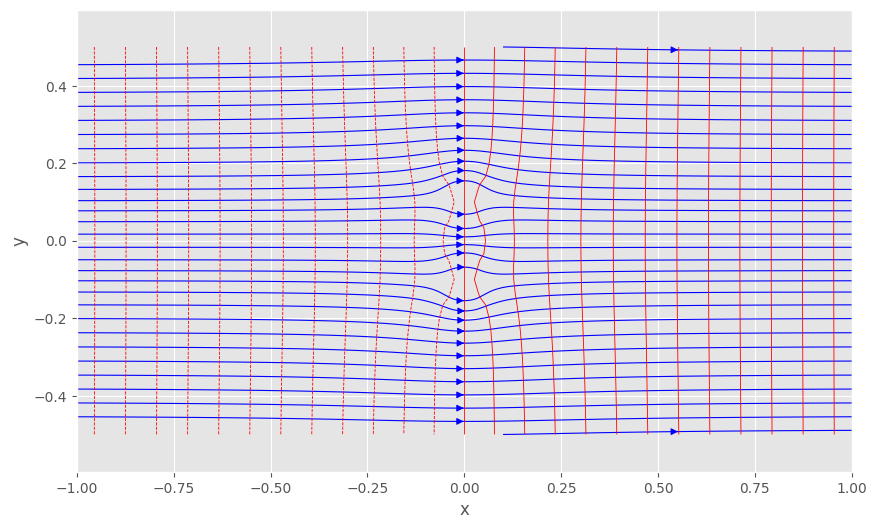

In [4]:
xi, xf = -1, 1
yi, yf = -0.5, 0.5

nx = 51
ny = 31

x = np.linspace(xi, xf, nx)
y = np.linspace(yi, yf, ny)

X, Y = np.meshgrid(x, y)

P = np.zeros((ny, nx))

u = 1
v = 0
P = uniform_flow(P, X, Y, u, v)

q = 10
x0, y0 = -0.001, 0.1
P = source_flow(P, X, Y, x0, y0, q)

q = -10
x0, y0 = 0.001, 0.1
P = source_flow(P, X, Y, x0, y0, q)

q = 10
x0, y0 = -0.001, -0.1
P = source_flow(P, X, Y, x0, y0, q)

q = -10
x0, y0 = 0.001, -0.1
P = source_flow(P, X, Y, x0, y0, q)

plot_flow(P, X, Y)